# Day 7 Notebook

## Exercise: Linear Regression

In [1]:
import numpy as np

In [2]:
y_vector = np.array(np.arange(8)).T # shape: (8,)
X_matrix = np.hstack([
    np.ones((8,1)),
    np.sqrt(np.arange(8*4)).reshape(8,4)
]) # shape: (8,5)

print(y_vector.shape)
print(X_matrix.shape)

(8,)
(8, 5)


In [3]:
X_pinv = np.linalg.pinv(X_matrix)
w_pinv_method = X_pinv @ y_vector

print(w_pinv_method)

[ -19.13512146  -12.39983252  184.11013704 -396.71057275  228.66445803]


In [4]:
X_formula = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T
w_formula_method = X_formula @ y_vector

print(w_formula_method)

[ -19.13512504  -12.39983948  184.11022702 -396.71075017  228.66455279]


In [5]:
err = (X_matrix @ w_formula_method - y_vector)

In [6]:
print(err.shape)

(8,)


In [7]:
mse = (err**2).mean()
print(mse)

6.017971110998606e-05


## Application: Band Gap Prediction

In [8]:
import requests

CSV_URL = 'https://raw.githubusercontent.com/cburdine/materials-ml-workshop/main/MaterialsML/regression/bandgaps.csv'

r = requests.get(CSV_URL)
with open('bandgaps.csv', 'w', encoding='utf-8') as f:
    f.write(r.text)

In [9]:
import pandas as pd

data_df = pd.read_csv('bandgaps.csv')

In [10]:
display(data_df)

,mp_id,formula,composition,crystal_system,symmetry_symbol,volume,density,e_fermi,formation_energy_per_atom,band_gap,bandgap_direct
0,mp-1005,FeP,"{'Fe': 1, 'P': 1}",Orthorhombic,Pnma,90.583862,6.366076,9.163143,-0.598423,0.0000,False
1,mp-1006367,Ce2HfSe5,"{'Ce': 2, 'Hf': 1, 'Se': 5}",Orthorhombic,Pnma,785.754385,7.215011,6.181067,-1.941463,0.0000,False
2,mp-1001606,LuFeC2,"{'Lu': 1, 'Fe': 1, 'C': 2}",Orthorhombic,Amm2,45.919844,9.215206,5.530327,-0.286076,0.0000,False
3,mp-1001613,LuGa,"{'Lu': 1, 'Ga': 1}",Orthorhombic,Cmcm,87.819318,9.253483,3.090952,-0.608621,0.0000,False
4,mp-1008624,YBiPd,"{'Y': 1, 'Bi': 1, 'Pd': 1}",Cubic,F-43m,74.987877,8.952998,5.397804,-0.961384,0.0000,False
...,...,...,...,...,...,...,...,...,...,...,...
29190,mp-555534,K4MnMo4O15,"{'K': 4, 'Mn': 1, 'Mo': 4, 'O': 15}",Trigonal,P-3,808.366683,3.430836,0.147938,-2.154358,2.9808,False
29191,mp-23703,LiH,"{'Li': 1, 'H': 1}",Cubic,Fm-3m,16.207758,0.814396,-0.997677,-0.495530,2.9810,True
29192,mp-561093,Rb2Cr2O7,"{'Rb': 2, 'Cr': 2, 'O': 7}",Monoclinic,P2_1/c,793.897416,3.237203,-1.868672,-1.934791,2.9814,True
29193,mp-16180,Na6S2O9,"{'Na': 6, 'S': 2, 'O': 9}",Cubic,Fm-3m,218.925628,2.624871,1.735700,-2.095472,2.9814,False


In [11]:
# Generate a list of elements in the dataset:
ELEMENTS = set()
for v in data_df['composition'].values:
    ELEMENTS |= set(eval(v).keys())
ELEMENTS = sorted(ELEMENTS)

# Generate a list of the crystal systems in the dataset:
CRYSTAL_SYSTEMS = sorted(set(data_df['crystal_system']))

# print the sizes of ELEMENTS and CRYSTAL_SYSTEMS
print('Number of elements:', len(ELEMENTS))
print('Number of crystal systems:', len(CRYSTAL_SYSTEMS))

Number of elements: 86
Number of crystal systems: 7


In [12]:
CRYSTAL_SYSTEMS

['Cubic',
 'Hexagonal',
 'Monoclinic',
 'Orthorhombic',
 'Tetragonal',
 'Triclinic',
 'Trigonal']

In [13]:
import numpy as np

def vectorize_composition(composition, elements):
    """ Converts and element composition dictionary to a vector. """
    total_n = sum(composition.values())
    vec = np.zeros(len(elements))
    for elem, n in composition.items():
        vec[elements.index(elem)] = n/total_n

    return vec

def vectorize_crystal_system(crystal_system, systems):
    """ Converts a crystal system to a vector. """
    vec = np.zeros(len(systems))
    if crystal_system in systems:
        vec[systems.index(crystal_system)] = 1.0

    return vec

In [14]:
test_comp = { 'Si' : 1, 'O': 2 }
print(vectorize_composition(
    test_comp,
    ['Si', 'C', 'O']
))

[0.33333333 0.         0.66666667]


In [15]:
test_system = 'Hexagonal'

print(vectorize_crystal_system(
    test_system,
    systems = CRYSTAL_SYSTEMS
))

[0. 1. 0. 0. 0. 0. 0.]


In [16]:
def parse_data_vector(row):
    """ parses x and y vectors from a dataframe row """
    
    # parse whether or not the band gap is direct: 
    bandgap_direct = 1.0 if row['bandgap_direct'] else -1.0
    
    # parse the composition dict:
    composition_dict = eval(row['composition'])
    
    # parse feature vector (x):
    x_vector = np.concatenate([
        vectorize_composition(composition_dict, ELEMENTS),
        vectorize_crystal_system(row['crystal_system'], CRYSTAL_SYSTEMS),
        np.array([ row['volume'] ]),
        np.array([ row['density'] ]),
        np.array([ row['formation_energy_per_atom'] ]),
    ])
    
    # parse label vector (y):
    y_vector = np.concatenate([
        np.array([ row['band_gap'] ]),
        np.array([ bandgap_direct ])
    ])
    
    return x_vector, y_vector

In [17]:
data_x, data_y = [], []
for i, row in data_df.iterrows():
    x_vector, y_vector = parse_data_vector(row)
    data_x.append(x_vector)
    data_y.append(y_vector)

data_x = np.array(data_x)
data_y = np.array(data_y)

In [18]:
print(data_x.shape)
print(data_y.shape)

(29195, 96)
(29195, 2)


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def train_val_test_split(data_x, data_y, split=(0.8,0.1,0.1)):
    """ splits data into train, validation, and test sets. """
    
    # split train and nontrain data:
    train_x, nontrain_x, train_y, nontrain_y = \
        train_test_split(
            data_x, data_y, train_size=split[0]/sum(split))
    
    # split validation and test data:
    val_x, test_x, val_y, test_y = \
        train_test_split(
            data_x, data_y, 
            test_size=split[2]/(split[1]+split[2]))
    
    return (train_x, val_x, test_x), \
           (train_y, val_y, test_y)
    
def standardize(train_x, val_x, test_x):
    """ standardizes a dataset. """
    
    scaler = StandardScaler()
    train_z = scaler.fit_transform(train_x)
    val_z = scaler.transform(val_x)
    test_z = scaler.transform(test_x)
    return scaler, train_z, val_z, test_z

In [20]:
metals_y = np.array([ 
    1.0 if y[0] <= 0 else -1.0 
    for y in data_y 
])

subsets_x, subsets_y = train_val_test_split(data_x, metals_y)

train_x, val_x, test_x = subsets_x
train_y, val_y, test_y = subsets_y

In [21]:
scaler, train_z, val_z, test_z = \
    standardize(train_x, val_x, test_x)

In [22]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = RidgeClassifier(alpha=1.0)
model.fit(train_z, train_y)

RidgeClassifier()

In [23]:
train_yhat = model.predict(train_z)
val_yhat = model.predict(val_z)

[]

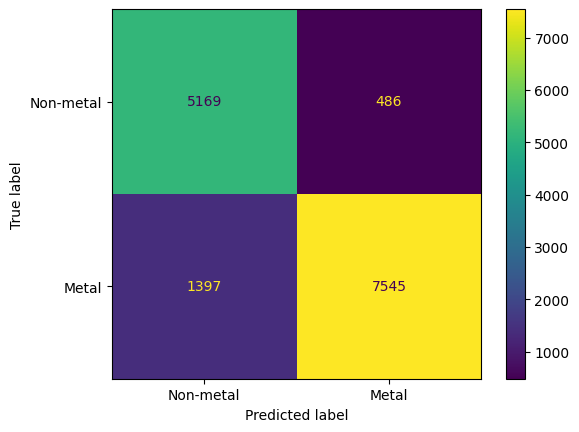

In [28]:
import matplotlib.pyplot as plt

cm = confusion_matrix(val_y, val_yhat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.gca().set_xticklabels(['Non-metal', 'Metal'])
plt.gca().set_yticklabels(['Non-metal', 'Metal'])
plt.plot()

In [29]:
print(cm)

[[5169  486]
 [1397 7545]]


In [31]:
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(accuracy)

0.8710008905939577


In [32]:
# extract all materials where the band gap is > 0 (insulator):
bandgap_x = data_x[data_y[:,0] > 0]
bandgap_y = data_y[(data_y[:,0] > 0),0]

print('bandgap_x shape:', bandgap_x.shape)
print('bandgap_y shape:', bandgap_y.shape)

bandgap_x shape: (11464, 96)
bandgap_y shape: (11464,)


In [33]:
bandgap_subsets_x, bandgap_subsets_y = \
    train_val_test_split(bandgap_x, bandgap_y)

train_x, val_x, test_x = bandgap_subsets_x
train_y, val_y, test_y = bandgap_subsets_y

scaler, train_z, val_z, test_z = \
    standardize(train_x, val_x, test_x)

In [34]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(train_z, train_y)

Ridge()

In [35]:
train_yhat = ridge_model.predict(train_z)
val_yhat = ridge_model.predict(val_z)

# evaluate the MSE on the training/validation sets:
train_mse = np.mean((train_yhat - train_y)**2)
val_mse = np.mean((val_yhat - val_y)**2)

# evaluate the training/validation error:
print('training stddev:', np.std(train_y))
print('training MSE:', train_mse)
print('validation MSE:', val_mse)
print('validation RMSE/stddev:', np.sqrt(val_mse)/np.std(train_y))

training stddev: 0.8652249765383488
training MSE: 0.44550844643701015
validation MSE: 0.4390335150312045
validation RMSE/stddev: 0.7658078073168179


In [37]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbr = HistGradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.1,
    max_leaf_nodes=128
)

hgbr.fit(train_z, train_y)

HistGradientBoostingRegressor(max_leaf_nodes=128)

In [38]:
train_yhat = hgbr.predict(train_z)
val_yhat = hgbr.predict(val_z)

In [40]:
train_mse = np.mean((train_yhat - train_y)**2)
val_mse = np.mean((val_yhat - val_y)**2)

# print the training/validation error
print('training stddev:', np.std(train_y))
print('training MSE:', train_mse)
print('validation MSE:', val_mse)
print('validation RMSE/stddev:', np.sqrt(val_mse)/np.std(train_y))

training stddev: 0.8652249765383488
training MSE: 0.08728978354392748
validation MSE: 0.1272153522504517
validation RMSE/stddev: 0.41223106337793514
